In [1]:
pip install pandas scikit-learn numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Data PreProcessing

In [9]:
# ============================================
# Diabetes Prediction - Data Preprocessing
# ============================================

import pandas as pd
from sklearn.preprocessing import LabelEncoder

# --------------------------------------------
# 1. Load Dataset
# --------------------------------------------

input_path = r"D:\Ajmal KT\Diabetes_Prediction\diabetes_prediction_dataset.csv"

df = pd.read_csv(input_path)

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")


# --------------------------------------------
# 2. Display First 5 Rows
# --------------------------------------------

print("\nFirst 5 rows of the dataset:")
display(df.head())


# --------------------------------------------
# 3. Dataset Information
# --------------------------------------------

print("\nDataset Information:")
df.info()


# --------------------------------------------
# 4. Check Unique Values
# --------------------------------------------

print("\nUnique values in Gender:")
print(df["gender"].unique())

print("\nUnique values in Smoking History:")
print(df["smoking_history"].unique())


# --------------------------------------------
# 5. Check Missing Values
# --------------------------------------------

print("\nMissing values:")
print(df.isnull().sum())


# --------------------------------------------
# 6. Check Duplicate Rows
# --------------------------------------------

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())


# --------------------------------------------
# 7. Remove Duplicate Rows
# --------------------------------------------

df = df.drop_duplicates()

print("\nShape after removing duplicates:")
print(df.shape)


# --------------------------------------------
# 8. Encode Categorical Variables
# --------------------------------------------

gender_encoder = LabelEncoder()
smoking_encoder = LabelEncoder()

df["gender"] = gender_encoder.fit_transform(df["gender"])
df["smoking_history"] = smoking_encoder.fit_transform(df["smoking_history"])


# --------------------------------------------
# 9. Display Encoded Data
# --------------------------------------------

print("\nEncoded dataset:")
display(df.head())


# --------------------------------------------
# 10. Save Preprocessed Dataset
# --------------------------------------------

output_path = r"D:\Ajmal KT\Diabetes_Prediction\preprocessed_diabetes_data.csv"

df.to_csv(output_path, index=False)

print("\nData preprocessing completed successfully!")
print(f"Preprocessed dataset saved to:\n{output_path}")

Dataset loaded successfully!
Dataset shape: (100000, 9)

First 5 rows of the dataset:


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0



Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB

Unique values in Gender:
<StringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str

Unique values in Smoking History:
<StringArray>
['never', 'No Info', 'current', 'former', 'ever', 'not current']
Length: 6, dtype: str

Missing values:
gender            

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,4,25.19,6.6,140,0
1,0,54.0,0,0,0,27.32,6.6,80,0
2,1,28.0,0,0,4,27.32,5.7,158,0
3,0,36.0,0,0,1,23.45,5.0,155,0
4,1,76.0,1,1,1,20.14,4.8,155,0



Data preprocessing completed successfully!
Preprocessed dataset saved to:
D:\Ajmal KT\Diabetes_Prediction\preprocessed_diabetes_data.csv


Checking Processed Dataset

In [10]:
import pandas as pd

df = pd.read_csv(
    r"D:\Ajmal KT\Diabetes_Prediction\preprocessed_diabetes_data.csv"
)

df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,4,25.19,6.6,140,0
1,0,54.0,0,0,0,27.32,6.6,80,0
2,1,28.0,0,0,4,27.32,5.7,158,0
3,0,36.0,0,0,1,23.45,5.0,155,0
4,1,76.0,1,1,1,20.14,4.8,155,0


Load and Prepare Data - For 'Diabetes_Prediction'

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the preprocessed dataset
data = pd.read_csv(
    r"D:\Ajmal KT\Diabetes_Prediction\preprocessed_diabetes_data.csv"
)

# Define features and target
Features = [
    'gender',
    'age',
    'hypertension',
    'heart_disease',
    'smoking_history',
    'bmi',
    'HbA1c_level',
    'blood_glucose_level'
]

Target = 'diabetes'

# Separate features and target variable
X = data[Features]
y = data[Target]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Display dataset shapes
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (76916, 8)
Test set shape: (19230, 8)


In [6]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Handle Class Imbalance - Oversampling with SMOTE 

In [12]:
# Handle Class Imbalance - Oversampling with SMOTE

from imblearn.over_sampling import SMOTE

# Check class distribution before SMOTE
print("Class distribution before SMOTE:")
print(y_train.value_counts())

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE only to the training data
X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled,
    y_train
)

# Check class distribution after SMOTE
print("\nClass distribution after SMOTE:")
print(y_train_resampled.value_counts())

# Display shapes
print("\nBefore SMOTE:")
print("X_train:", X_train_scaled.shape)
print("y_train:", y_train.shape)

print("\nAfter SMOTE:")
print("X_train_resampled:", X_train_resampled.shape)
print("y_train_resampled:", y_train_resampled.shape)

Class distribution before SMOTE:
diabetes
0    70130
1     6786
Name: count, dtype: int64

Class distribution after SMOTE:
diabetes
0    70130
1    70130
Name: count, dtype: int64

Before SMOTE:
X_train: (76916, 8)
y_train: (76916,)

After SMOTE:
X_train_resampled: (140260, 8)
y_train_resampled: (140260,)


Model Training and Hyperparameter Tuning

In [13]:
# Random Forest - Hyperparameter Tuning

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import time

# Define Random Forest model
rf_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# Hyperparameter distribution
param_dist = {
    'n_estimators': [100, 150, 200],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Stratified K-Fold Cross Validation
kf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Start training timer
start_time = time.time()

# Randomized Search
randomized_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist,
    n_iter=20,
    cv=kf,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

# Train using SMOTE-resampled training data
randomized_search.fit(
    X_train_resampled,
    y_train_resampled
)

# Calculate training time
end_time = time.time()
training_time = (end_time - start_time) / 60

# Get best model
best_rf_model = randomized_search.best_estimator_

print("\n========================================")
print("RANDOM FOREST TRAINING COMPLETED")
print("========================================")

print("\nBest Parameters:")
print(randomized_search.best_params_)

print(f"\nBest Cross-Validation F1 Score: "
      f"{randomized_search.best_score_:.4f}")

print(f"Training Time: {training_time:.2f} minutes")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

RANDOM FOREST TRAINING COMPLETED

Best Parameters:
{'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}

Best Cross-Validation F1 Score: 0.9789
Training Time: 4.22 minutes


Model Evaluation

       RANDOM FOREST MODEL EVALUATION

Accuracy  : 0.9619
Precision : 0.8092
Recall    : 0.7429
F1-Score  : 0.7747

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.98      0.98      0.98     17534
    Diabetes       0.81      0.74      0.77      1696

    accuracy                           0.96     19230
   macro avg       0.89      0.86      0.88     19230
weighted avg       0.96      0.96      0.96     19230

Confusion Matrix:
[[17237   297]
 [  436  1260]]


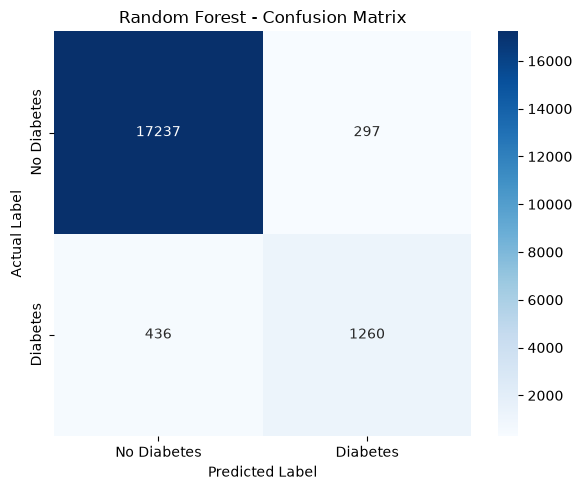

In [14]:
# ============================================
# Random Forest Model Evaluation
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt

# --------------------------------------------
# 1. Prediction on Test Data
# --------------------------------------------

y_pred = best_rf_model.predict(X_test_scaled)

# --------------------------------------------
# 2. Evaluation Metrics
# --------------------------------------------

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("============================================")
print("       RANDOM FOREST MODEL EVALUATION")
print("============================================")

print(f"\nAccuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

# --------------------------------------------
# 3. Classification Report
# --------------------------------------------

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Diabetes", "Diabetes"]
    )
)

# --------------------------------------------
# 4. Confusion Matrix
# --------------------------------------------

conf_matrix = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(conf_matrix)

# --------------------------------------------
# 5. Visualize Confusion Matrix
# --------------------------------------------

plt.figure(figsize=(6, 5))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"]
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

Adjust Decision Threshold

ROC-AUC Score: 0.9650
Optimal Threshold: 0.1167

Optimized Test Accuracy: 0.8732

Optimized Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.99      0.87      0.93     17534
    Diabetes       0.40      0.91      0.56      1696

    accuracy                           0.87     19230
   macro avg       0.70      0.89      0.74     19230
weighted avg       0.94      0.87      0.89     19230



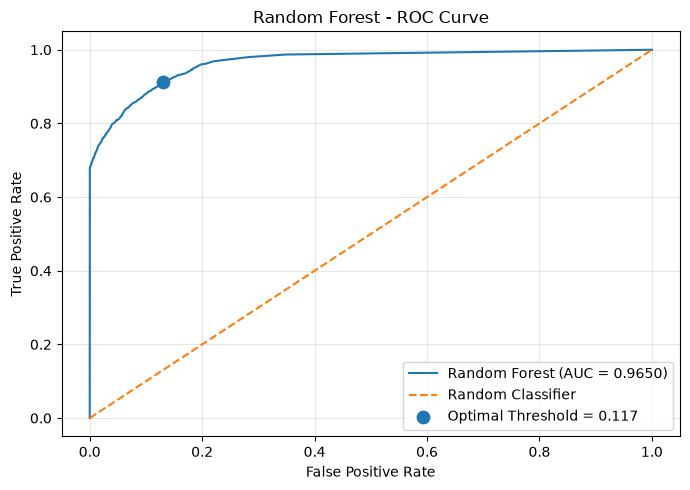

In [15]:
# ============================================
# ROC Curve and Optimal Threshold
# ============================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    accuracy_score,
    classification_report
)

# --------------------------------------------
# 1. Get probability predictions
# --------------------------------------------

y_prob = best_rf_model.predict_proba(X_test_scaled)[:, 1]

# --------------------------------------------
# 2. Calculate ROC Curve
# --------------------------------------------

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

# --------------------------------------------
# 3. Calculate ROC-AUC Score
# --------------------------------------------

auc_score = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC Score: {auc_score:.4f}")

# --------------------------------------------
# 4. Find Optimal Threshold
# --------------------------------------------

optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal Threshold: {optimal_threshold:.4f}")

# --------------------------------------------
# 5. Apply Optimal Threshold
# --------------------------------------------

y_pred_optimal = (
    y_prob >= optimal_threshold
).astype(int)

# --------------------------------------------
# 6. Evaluate Optimized Predictions
# --------------------------------------------

optimized_accuracy = accuracy_score(
    y_test,
    y_pred_optimal
)

print(f"\nOptimized Test Accuracy: {optimized_accuracy:.4f}")

print("\nOptimized Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_optimal,
        target_names=["No Diabetes", "Diabetes"]
    )
)

# --------------------------------------------
# 7. Plot ROC Curve
# --------------------------------------------

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {auc_score:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

# Mark optimal threshold
plt.scatter(
    fpr[optimal_idx],
    tpr[optimal_idx],
    s=80,
    label=f"Optimal Threshold = {optimal_threshold:.3f}"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest - ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Trained Machine Learning Model - 'Diabetes Prediction'

In [16]:
# ============================================
# Save Best Model and Scaler
# ============================================

import pickle
import os

# Project folder
project_path = r"D:\Ajmal KT\Diabetes_Prediction"

# File paths
model_path = os.path.join(
    project_path,
    "Diabetes_Prediction_Model.pkl"
)

scaler_path = os.path.join(
    project_path,
    "Diabetes_Prediction_Scaler.pkl"
)

# Save the best Random Forest model
with open(model_path, "wb") as model_file:
    pickle.dump(best_rf_model, model_file)

# Save the StandardScaler
with open(scaler_path, "wb") as scaler_file:
    pickle.dump(scaler, scaler_file)

print("============================================")
print("MODEL AND SCALER SAVED SUCCESSFULLY")
print("============================================")
print(f"Model : {model_path}")
print(f"Scaler: {scaler_path}")

MODEL AND SCALER SAVED SUCCESSFULLY
Model : D:\Ajmal KT\Diabetes_Prediction\Diabetes_Prediction_Model.pkl
Scaler: D:\Ajmal KT\Diabetes_Prediction\Diabetes_Prediction_Scaler.pkl
